In [4]:
#membaca dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df = pd.read_csv("indotoxic2024_annotated_data_v2_final.csv")
df.head(5)

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit
0,1-1,"['7', '15']",Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,“️Jurnalis Hana Mahamed kembali tampil di tele...,UNKNOWN,"['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
1,1-10,"['7', '15']",Elektabilitas Paslon 02 sebentar lagi terjun b...,NaN,Disabilitas,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
2,1-100,"['7', '15']",Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,NaN,Disabilitas,"['0', '0']","['1', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['1', '0']","['0', '0']","['0', '0']"
3,1-1000,"['7', '15']",Relawan Tionghoa Kalbar yg di Jakarta mendekla...,NaN,Tionghoa,"['0', '0']","['1', '1']","['0', '0']","['1', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"
4,1-1001,"['10', '18']","Kristen, Hindu, Islam dapat perlakuan istimewa...",NaN,Kristen,"['0', '0']","['1', '1']","['0', '0']","['1', '1']","['0', '0']","['0', '0']","['0', '0']","['0', '0']","['0', '0']"


In [5]:
# cek ukuran data
df.shape

(28448, 14)

In [6]:
#melihat informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28448 entries, 0 to 28447
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   text_id                        28448 non-null  object
 1   annotators_id                  28448 non-null  object
 2   text                           28447 non-null  object
 3   initial_paragraph              1669 non-null   object
 4   topic                          28448 non-null  object
 5   is_noise_or_spam_text          28448 non-null  object
 6   related_to_election_2024       28448 non-null  object
 7   toxicity                       28448 non-null  object
 8   polarized                      28448 non-null  object
 9   profanity_obscenity            28448 non-null  object
 10  threat_incitement_to_violence  28448 non-null  object
 11  insults                        28448 non-null  object
 12  identity_attack                28448 non-null  object
 13  s

In [7]:
#cek missing value
df.isnull().sum()

text_id                              0
annotators_id                        0
text                                 1
initial_paragraph                26779
topic                                0
is_noise_or_spam_text                0
related_to_election_2024             0
toxicity                             0
polarized                            0
profanity_obscenity                  0
threat_incitement_to_violence        0
insults                              0
identity_attack                      0
sexually_explicit                    0
dtype: int64

In [8]:
#cek duplikat
df.duplicated().sum()

np.int64(0)

In [9]:
df['toxicity'].value_counts()

toxicity
['0']                                                                                    15059
['0', '0']                                                                                5955
['0', '0', '0']                                                                           1311
['1', '0']                                                                                 913
['0', '0', '0', '0']                                                                       698
                                                                                         ...  
['1', '1', '1', '1', '1', '1', '1', '0', '1', '1', '0', '1', '1', '0', '0']                  1
['0', '1', '0', '0', '1', '1', '0', '0', '0', '0', '0', '0', '1']                            1
['1', '1', '0', '1', '0', '1', '0', '1', '0', '0', '0', '0', '1', '0', '0', '0', '0']        1
['1', '1', '1', '1', '1', '1', '1', '1', '1', '0', '1', '1', '1', '0', '0', '1', '0']        1
['1', '1', '1', '1', '0', '0', '1', '1', 

In [13]:
import ast

def convert_label(x):
    labels = ast.literal_eval(x)
    
    if labels.count('1') > labels.count('0'):
        return 1
    else:
        return 0

df['toxicity_label'] = df['toxicity'].apply(convert_label)
df['toxicity_label'].value_counts()

toxicity_label
0    26292
1     2156
Name: count, dtype: int64

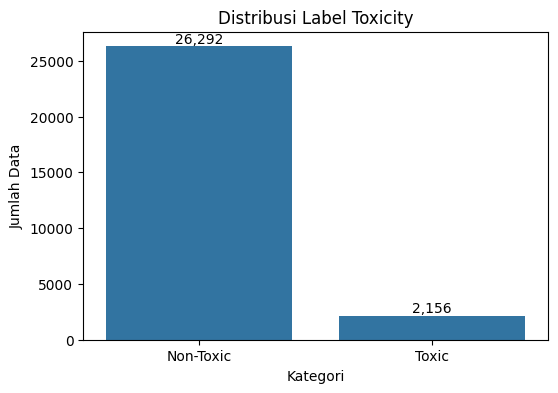

In [16]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    x='toxicity_label',
    data=df
)
plt.title('Distribusi Label Toxicity')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')

plt.xticks(
    [0,1],
    ['Non-Toxic','Toxic']
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

In [17]:
#menambahkan kolom
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

df[['text','text_length']].head()

,text,text_length
0,Wajah Jurnalis Dibalut Perban Saat Melaporkan ...,10
1,Elektabilitas Paslon 02 sebentar lagi terjun b...,22
2,Gini aja deh @KPU_ID usul aja nih. Gimana kalo...,39
3,Relawan Tionghoa Kalbar yg di Jakarta mendekla...,22
4,"Kristen, Hindu, Islam dapat perlakuan istimewa...",11


In [18]:
df['text_length'].describe()

count    28448.000000
mean        43.897075
std         71.043878
min          1.000000
25%         12.000000
50%         22.000000
75%         39.000000
max        880.000000
Name: text_length, dtype: float64

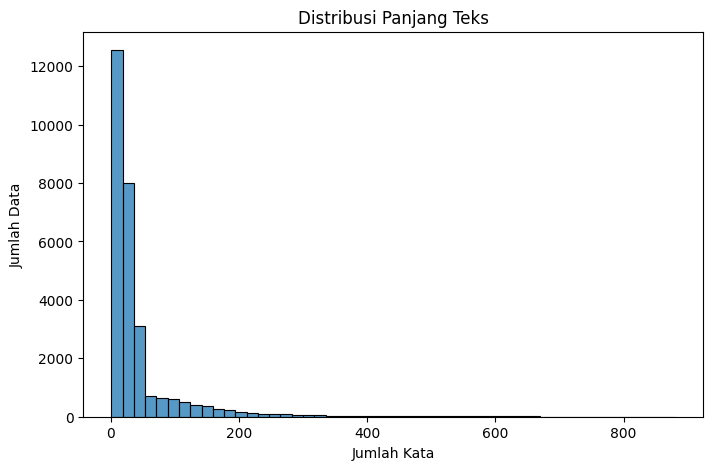

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['text_length'],
    bins=50
)

plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Data")

plt.show()

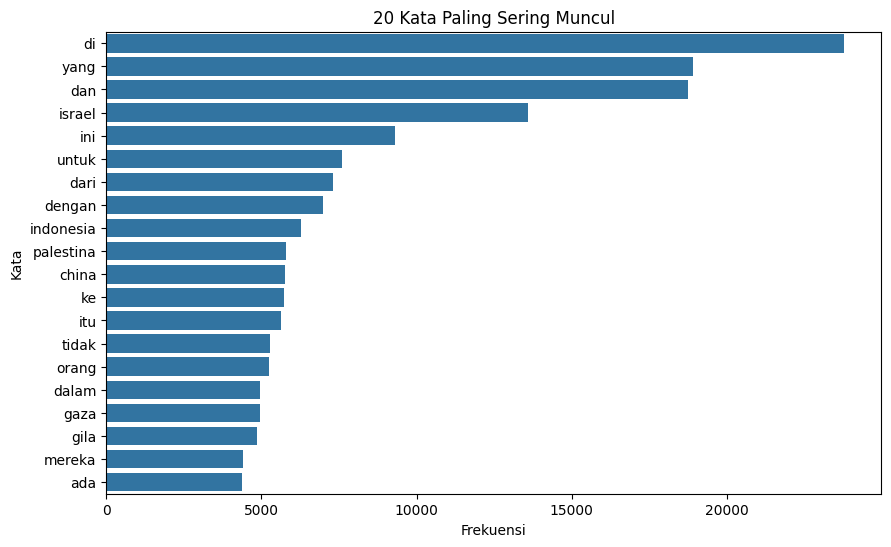

In [21]:
# ambil 20 kata teratas
top_words = word_freq.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]


plt.figure(figsize=(10,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("20 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.show()